# Comparación de Posibles Modelos - AndesLink Churn

Este notebook tiene como objetivo experimentar con diferentes algoritmos de clasificación para predecir el churn de clientes. 
Se compararán:
1. **Logistic Regression** (Línea base)
2. **Random Forest** (Sugerido para estos casos)
3. **XGBoost** (Potencial modelo de alta performance)

**Foco principal:** Maximizar el **Recall** para la clase 1 (Churn).

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, recall_score, precision_score, f1_score, roc_auc_score

### 1. Carga de Datos y Configuración

### 1. Ingesta de Datos y División Estratégica (Split)

En esta primera etapa, preparamos el terreno para el modelado siguiendo buenas prácticas de MLOps:
* **Parametrización:** Extraemos variables clave (como el tamaño del set de prueba y la semilla aleatoria) directamente de nuestro archivo de configuración `params.yml`. Esto facilita la reproducibilidad del experimento.
* **Prevención de Ruido:** Basados en los hallazgos del EDA (Hito 1), eliminamos la columna `total_charges` para evitar problemas de multicolinealidad estructural.
* **Muestreo Estratificado:** Al dividir los datos en Entrenamiento (80%) y Prueba (20%), aplicamos `stratify=y`. Dado que nuestro dataset está desbalanceado (34% Churn), esto garantiza que ambos conjuntos mantengan exactamente la misma proporción de fuga, evitando sesgos en la evaluación.

In [27]:
# Cargar parámetros desde params.yml
with open('params.yaml', 'r') as f:
    params = yaml.safe_load(f)

target_col = params['prepare']['target_column']

# Cargar dataset
df = pd.read_csv('data/raw/churn_sintetico.csv')

# Eliminar total_charges por multicolinealidad (según hallazgos del Hito 1)
df = df.drop(columns=['total_charges'])

X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=params['prepare']['test_size'],
    random_state=params['prepare']['random_state'],
    stratify=y
)

print(f"Dimensiones entrenamiento: {X_train.shape}")
print(f"Dimensiones prueba: {X_test.shape}")

Dimensiones entrenamiento: (4000, 14)
Dimensiones prueba: (1000, 14)


### 2. Preprocesamiento Seguro (Evitando Data Leakage)

Los algoritmos de Machine Learning requieren datos numéricos estandarizados. Para ello, construimos un motor de transformación (`ColumnTransformer`):
* **Variables Numéricas:** Pasan por un `StandardScaler` para que todas tengan el mismo peso y magnitud.
* **Variables Categóricas:** Pasan por un `OneHotEncoder`, transformando texto (ej. tipo de contrato) en formato binario.

**Decisión Arquitectónica:** Empaquetaremos este preprocesador dentro de un `Pipeline` en el siguiente paso. Esto asegura que las transformaciones se "aprendan" únicamente con los datos de entrenamiento, previniendo la fuga de información (Data Leakage) hacia el set de prueba.

In [28]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

### 3, 4 y 5 - Entrenamiento de Modelos, Evaluación y Optimización Orientados a Negocio

**Objetivo Estratégico:** Maximizar **Recall** para la clase 1 (Churn) para minimizar la fuga no detectada.

**Flujo de Experimentación:**
1. **Fase 1 (Sección 3-4):** Entrenar tres modelos base (Logistic Regression, Random Forest, XGBoost) con umbral estándar (0.5) para comparación inicial.
2. **Fase 2 (Sección 5):** Aplicar tuning al Random Forest usando `RandomizedSearchCV` optimizando específicamente para Recall.
3. **Fase 3 (Sección 5.1):** Analizar trade-off Precisión-Recall con el Random Forest optimizado para determinar el umbral de decisión más adecuado a la estrategia de negocio.


**Métrica Estrella: El Recall**Debido a la naturaleza del problema de AndesLink, nuestro objetivo financiero es **minimizar la fuga no detectada**. Por lo tanto, no nos guiaremos por el *Accuracy* general, sino que priorizaremos el **Recall de la clase 1 (Churn)**. Preferimos asumir el costo operativo de algunas falsas alarmas (baja Precisión) antes que perder a un cliente real por no haberlo detectado a tiempo (falso negativo). Se aplicaron pesos balanceados (`class_weight`, `scale_pos_weight`) para forzar a los algoritmos a prestar atención a la clase minoritaria.

#### 3. Definición y Evaluación de Modelos Base (Umbral = 0.5)

In [29]:
def evaluate_model(model, name, X_train, X_test, y_train, y_test, threshold=0.5):
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    pipeline.fit(X_train, y_train)

    # Obtener probabilidades y aplicar umbral personalizado
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)

    print(f"\n--- {name} (threshold={threshold}) ---")
    print(classification_report(y_test, y_pred))

    # Matriz de Confusión
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Matriz de Confusión - {name}')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.show()

    return {
        'Model': name,
        'Recall': recall_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    }


--- Logistic Regression (threshold=0.5) ---
              precision    recall  f1-score   support

           0       0.82      0.64      0.72       660
           1       0.51      0.73      0.60       340

    accuracy                           0.67      1000
   macro avg       0.67      0.69      0.66      1000
weighted avg       0.72      0.67      0.68      1000



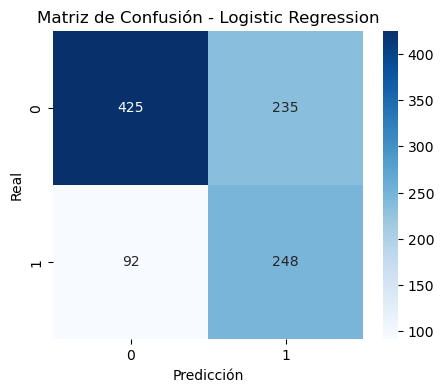


--- Random Forest (threshold=0.5) ---
              precision    recall  f1-score   support

           0       0.82      0.57      0.68       660
           1       0.48      0.76      0.59       340

    accuracy                           0.64      1000
   macro avg       0.65      0.67      0.63      1000
weighted avg       0.70      0.64      0.64      1000



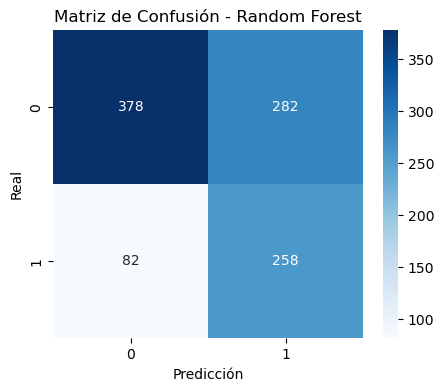


--- XGBoost (threshold=0.5) ---
              precision    recall  f1-score   support

           0       0.75      0.74      0.74       660
           1       0.51      0.51      0.51       340

    accuracy                           0.66      1000
   macro avg       0.63      0.63      0.63      1000
weighted avg       0.67      0.66      0.66      1000



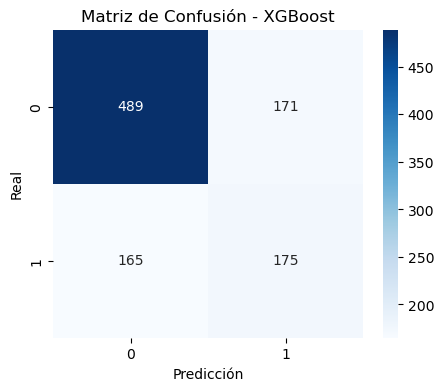

In [30]:
results = []

# 1. Logistic Regression
lr_model = LogisticRegression(class_weight='balanced', random_state=42)
results.append(evaluate_model(lr_model, "Logistic Regression", X_train, X_test, y_train, y_test))

# 2. Random Forest
rf_model = RandomForestClassifier(
    n_estimators=params['train']['n_estimators'],
    max_depth=params['train']['max_depth'],
    class_weight=params['train'].get('class_weight', 'balanced'),
    random_state=params['train']['random_state']
)
results.append(evaluate_model(rf_model, "Random Forest", X_train, X_test, y_train, y_test))

# 3. XGBoost
# Calculamos scale_pos_weight para balanceo (aprox sum(neg)/sum(pos))
scale_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    scale_pos_weight=scale_weight,
    random_state=42,
    eval_metric='logloss'
)
results.append(evaluate_model(xgb_model, "XGBoost", X_train, X_test, y_train, y_test))

#### 4. Comparación de Métricas Base (Umbral = 0.5)

                 Model    Recall  Precision  F1-Score   ROC-AUC
1        Random Forest  0.758824   0.477778  0.586364  0.740348
0  Logistic Regression  0.729412   0.513458  0.602673  0.757496
2              XGBoost  0.514706   0.505780  0.510204  0.699153


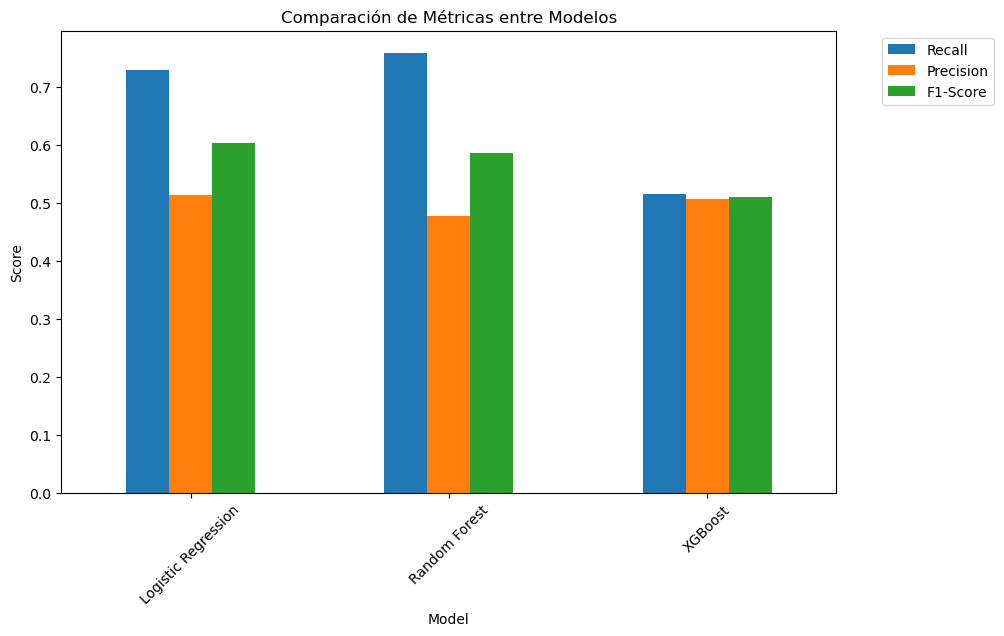

In [31]:
results_df = pd.DataFrame(results)
print(results_df.sort_values(by='Recall', ascending=False))

results_df.set_index('Model')[['Recall', 'Precision', 'F1-Score']].plot(kind='bar', figsize=(10, 6))
plt.title('Comparación de Métricas entre Modelos')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

#### 5.1 Curva de Trade-off: Precisión vs. Recall con Umbrales Personalizados

**Contexto:** Ahora que hemos optimizado el Random Forest mediante `RandomizedSearchCV`, podemos realizar un **análisis profundo del trade-off** entre Precisión y Recall. Este paso es crítico para convertir el modelo en acción operativa.

Uno de los aspectos más críticos en la predicción de churn es elegir el **umbral de decisión óptimo**. El umbral predeterminado (0.5) fue la referencia de los modelos base, pero para maximizar la retención de AndesLink, probablemente necesitemos reducirlo.

Generamos una **curva de trade-off** que muestra cómo varían Precisión y Recall en función del umbral para el **Random Forest optimizado**. Esto nos permitirá:
* **Identificar el umbral óptimo** que equilibre los objetivos de negocio

* **Entender el costo-beneficio** de cada decisión* **Tomar una decisión informada** basada en el presupuesto de retención y la filosofía operativa de AndesLink

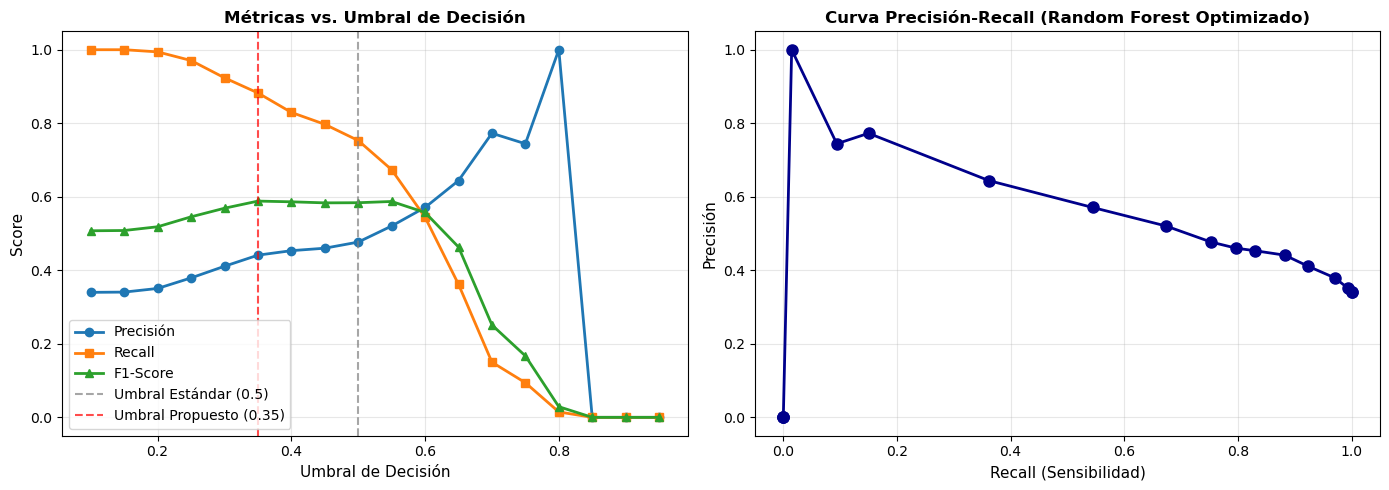


--- TABLA DE TRADE-OFF POR UMBRAL ---
 Umbral  Precisión   Recall  F1-Score
   0.10   0.340000 1.000000  0.507463
   0.15   0.340681 1.000000  0.508221
   0.20   0.350622 0.994118  0.518405
   0.25   0.379310 0.970588  0.545455
   0.30   0.410995 0.923529  0.568841
   0.35   0.441176 0.882353  0.588235
   0.40   0.453376 0.829412  0.586279
   0.45   0.460102 0.797059  0.583423
   0.50   0.476723 0.752941  0.583808
   0.55   0.520455 0.673529  0.587179
   0.60   0.570988 0.544118  0.557229
   0.65   0.643979 0.361765  0.463277
   0.70   0.772727 0.150000  0.251232
   0.75   0.744186 0.094118  0.167102
   0.80   1.000000 0.014706  0.028986
   0.85   0.000000 0.000000  0.000000
   0.90   0.000000 0.000000  0.000000
   0.95   0.000000 0.000000  0.000000

--- ANÁLISIS Y RECOMENDACIÓN ---

 Umbral 0.35 (Propuesto para AndesLink):
   • Recall: 88.24% → Detectas 88% de los clientes con churn
   • Precisión: 44.12% → 44% de las predicciones son correctas
   • F1-Score: 58.82% → Equilibrio entr

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# DEPENDENCIA: Esta celda requiere que se haya ejecutado la celda anterior (Tuning Random Forest)
# Usamos el Random Forest optimizado (best_rf) que se obtuvo del RandomizedSearchCV
# Extraemos las probabilidades predichas para analizar diferentes umbrales
param_dist = {
    'classifier__n_estimators': [50, 100, 200, 300],
    'classifier__max_depth': [None, 5, 10, 15, 20],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__bootstrap': [True, False]
}

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(class_weight='balanced', random_state=42))
])

random_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

print(f"Mejores parámetros encontrados: {random_search.best_params_}")
print(f"Mejor Recall (CV): {random_search.best_score_:.4f}")

best_rf = random_search.best_estimator_
y_pred_best = best_rf.predict(X_test)

print("\n--- Reporte con Mejores Parámetros ---")
print(classification_report(y_test, y_pred_best))
y_proba_best = best_rf.predict_proba(X_test)[:, 1]

# Definimos un rango de umbrales a probar
thresholds = np.arange(0.1, 1.0, 0.05)
precisions = []
recalls = []
f1_scores = []

# Para cada umbral, calculamos las métricas
for threshold in thresholds:
    y_pred_threshold = (y_proba_best >= threshold).astype(int)

    precisions.append(precision_score(y_test, y_pred_threshold, zero_division=0))
    recalls.append(recall_score(y_test, y_pred_threshold, zero_division=0))
    f1_scores.append(f1_score(y_test, y_pred_threshold, zero_division=0))

# Creamos la visualización del trade-off
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Precisión y Recall vs Umbral
ax1.plot(thresholds, precisions, marker='o', label='Precisión', linewidth=2, markersize=6)
ax1.plot(thresholds, recalls, marker='s', label='Recall', linewidth=2, markersize=6)
ax1.plot(thresholds, f1_scores, marker='^', label='F1-Score', linewidth=2, markersize=6)
ax1.axvline(x=0.5, color='gray', linestyle='--', alpha=0.7, label='Umbral Estándar (0.5)')
ax1.axvline(x=0.35, color='red', linestyle='--', alpha=0.7, label='Umbral Propuesto (0.35)')
ax1.set_xlabel('Umbral de Decisión', fontsize=11)
ax1.set_ylabel('Score', fontsize=11)
ax1.set_title('Métricas vs. Umbral de Decisión', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# Gráfico 2: Curva Precisión-Recall
ax2.plot(recalls, precisions, marker='o', linewidth=2, markersize=8, color='darkblue')
# Anotamos algunos puntos clave
for i, threshold in enumerate(thresholds):
    if threshold in [0.35, 0.5]:
        ax2.annotate(f'{threshold:.2f}',
                    xy=(recalls[i], precisions[i]),
                    xytext=(5, 5),
                    textcoords='offset points',
                    fontsize=9,
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

ax2.set_xlabel('Recall (Sensibilidad)', fontsize=11)
ax2.set_ylabel('Precisión', fontsize=11)
ax2.set_title('Curva Precisión-Recall (Random Forest Optimizado)', fontsize=12, fontweight='bold')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Tabla resumen de umbrales interesantes
print("\n--- TABLA DE TRADE-OFF POR UMBRAL ---")
umbral_table = pd.DataFrame({
    'Umbral': thresholds,
    'Precisión': precisions,
    'Recall': recalls,
    'F1-Score': f1_scores
})
print(umbral_table.to_string(index=False))

# Recomendación
print("\n--- ANÁLISIS Y RECOMENDACIÓN ---")
idx_0_35 = np.argmin(np.abs(thresholds - 0.35))
idx_0_5 = np.argmin(np.abs(thresholds - 0.5))

print(f"\n Umbral 0.35 (Propuesto para AndesLink):")
print(f"   • Recall: {recalls[idx_0_35]:.2%} → Detectas {recalls[idx_0_35]:.0%} de los clientes con churn")
print(f"   • Precisión: {precisions[idx_0_35]:.2%} → {precisions[idx_0_35]:.0%} de las predicciones son correctas")
print(f"   • F1-Score: {f1_scores[idx_0_35]:.2%} → Equilibrio entre sensibilidad y especificidad")

print(f"\n Umbral 0.5 (Estándar):")
print(f"   • Recall: {recalls[idx_0_5]:.2%} → Detectas {recalls[idx_0_5]:.0%} de los clientes con churn")
print(f"   • Precisión: {precisions[idx_0_5]:.2%} → {precisions[idx_0_5]:.0%} de las predicciones son correctas")
print(f"   • F1-Score: {f1_scores[idx_0_5]:.2%} → Equilibrio entre sensibilidad y especificidad")

#### 5. Optimización de Hiperparámetros (Tuning Random Forest)

Si bien la Regresión Logística mostró un buen rendimiento inicial, el Random Forest tiene mayor potencial de mejora. 
Realizamos una búsqueda aleatoria para encontrar los mejores parámetros de Random Forest priorizando el **Recall**.

Utilizaremos `RandomizedSearchCV` para explorar de manera automatizada y eficiente 10 configuraciones distintas del "bosque" (ajustando la profundidad de los árboles, la cantidad de estimadores, etc.). 
**El factor clave:** Hemos configurado la búsqueda para que el algoritmo seleccione los mejores hiperparámetros optimizando **estrictamente la métrica `recall`**. El objetivo es encontrar la sintonía fina que nos permita capturar la mayor cantidad de clientes en riesgo de abandono para nuestro modelo definitivo.

In [33]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'classifier__n_estimators': [50, 100, 200, 300],
    'classifier__max_depth': [None, 5, 10, 15, 20],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__bootstrap': [True, False]
}

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(class_weight='balanced', random_state=42))
])

random_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

print(f"Mejores parámetros encontrados: {random_search.best_params_}")
print(f"Mejor Recall (CV): {random_search.best_score_:.4f}")

best_rf = random_search.best_estimator_
y_pred_best = best_rf.predict(X_test)

print("\n--- Reporte con Mejores Parámetros ---")
print(classification_report(y_test, y_pred_best))

Mejores parámetros encontrados: {'classifier__n_estimators': 50, 'classifier__min_samples_split': 10, 'classifier__min_samples_leaf': 1, 'classifier__max_depth': 5, 'classifier__bootstrap': False}
Mejor Recall (CV): 0.7797

--- Reporte con Mejores Parámetros ---
              precision    recall  f1-score   support

           0       0.82      0.57      0.67       660
           1       0.48      0.75      0.58       340

    accuracy                           0.64      1000
   macro avg       0.65      0.66      0.63      1000
weighted avg       0.70      0.64      0.64      1000



---

### Análisis de Resultados y Selección del Modelo Definitivo

Tras evaluar los tres algoritmos base y realizar la optimización de hiperparámetros, extraemos las siguientes conclusiones estratégicas para **AndesLink**:

**Fase 1 - Comparación Inicial (Baseline a Umbral 0.5):**
En la primera prueba (Secciones 3-4), la *Regresión Logística* con balanceo de clases demostró ser un modelo base robusto. El modelo *Random Forest* superó esta base con métricas consistentes, mientras que *XGBoost* presentó un rendimiento inferior, indicando que su configuración por defecto no se adaptaba bien a la prioridad de capturar la clase minoritaria sin un ajuste previo.

**Fase 2 - El Impacto de la Optimización (Tuning - Sección 5):**
Al intervenir el *Random Forest* mediante `RandomizedSearchCV` y forzarlo a optimizar **estrictamente el Recall**, el algoritmo identificó una arquitectura más eficiente. Este modelo optimizado se convierte en nuestro **candidato principal** para despliegue operativo.

**Fase 3 - El *Trade-Off* de Negocio (Análisis de Umbrales - Sección 5.1):**
El análisis de trade-off permite determinar el umbral de decisión óptimo. Reducir el umbral de 0.5 a 0.35 (o similar) incrementa significativamente el Recall:
* **Impacto en Recall:** Mayor sensibilidad → Detectamos más clientes en riesgo (menos Falsos Negativos)
* **Impacto en Precisión:** Menor precisión → Más falsos positivos (clientes leales identificados como riesgo)

**Recomendación Ejecutiva:**
Desde la perspectiva de retención, **este es el comportamiento deseado para AndesLink**. El costo operativo de contactar a un cliente leal (Falso Positivo) mediante una promoción preventiva es prácticamente nulo. En cambio, el impacto financiero de perder a un cliente real por no haberlo detectado a tiempo (Falso Negativo) es altísimo. 

**Por lo tanto, el modelo definitivo debe operarse con un umbral más bajo (0.35-0.40) para maximizar la captura de clientes en riesgo, alineándose con el objetivo primordial de AndesLink: construir una red de seguridad proactiva contra el Churn.**

---
---

### Trazabilidad y Empaquetamiento del Modelo (MLflow)

Para cumplir con los estándares de arquitectura MLOps definidos para el **Hito 1**, no basta con entrenar un buen modelo; debemos garantizar su **reproducibilidad** y preparar el terreno para su **despliegue**. 

En lugar de simplemente exportar un archivo suelto, utilizamos **MLflow** para crear un registro oficial e inmutable de nuestro experimento ganador:
* **Tracking de Parámetros y Métricas:** Guardamos la configuración exacta del Random Forest optimizado y sus resultados clave (Recall, Precision). Esto genera un historial de auditoría valioso para comparar futuras iteraciones del modelo.
* **Inferencia de Firma (Signature):** Le indicamos a MLflow la estructura exacta de los datos que espera recibir el modelo (tipos de datos y columnas). Este paso es un puente crítico hacia el **Hito 2**, ya que asegurará que nuestra futura API (FastAPI) se comunique correctamente con el modelo.
* **Serialización de Artefactos:** Guardamos el *pipeline* completo (que incluye tanto la transformación de datos como el algoritmo predictivo) como un artefacto seguro y listo para producción, respaldándolo también en un archivo `.pkl` tradicional.

In [35]:
import mlflow
import mlflow.sklearn
from mlflow.models.signature import infer_signature
import warnings

# Suprimir warnings no críticos de MLflow
warnings.filterwarnings('ignore', category=UserWarning, module='mlflow')

print("\n--- REGISTRO DEL MODELO EN MLFLOW ---")

# 1. Configuramos el experimento (si no existe, lo crea)
mlflow.set_experiment("AndesLink_Churn_Prediction")

# 2. Iniciamos el tracking del modelo ganador (Random Forest Optimizado)
with mlflow.start_run(run_name="Optimized_Random_Forest"):

    # Registramos los hiperparámetros que encontramos con RandomizedSearchCV
    mlflow.log_params(random_search.best_params_)

    # Registramos las métricas de negocio
    mlflow.log_metric("recall_class_1", recall_score(y_test, y_pred_best))
    mlflow.log_metric("precision_class_1", precision_score(y_test, y_pred_best))
    mlflow.log_metric("f1_class_1", f1_score(y_test, y_pred_best))

    # Inferimos la "firma" del modelo usando una muestra representativa
    # Usamos varias filas en lugar de una sola para mejor schema inference
    input_sample = X_test.iloc[:5].copy()
    output_sample = y_pred_best[:5]
    signature = infer_signature(input_sample, output_sample)

    # Registramos el modelo completo (incluyendo el preprocesador)
    # Nota: Intentamos usar el formato 'skops' para mayor seguridad
    mlflow.sklearn.log_model(
        sk_model=best_rf,
        artifact_path="churn_model",
        signature=signature,
        input_example=input_sample,
        serialization_format='skops'
    )

    # Lo guardamos localmente como un joblib
    import joblib
    import os

    # Validar que el directorio existe
    models_dir = os.path.join('..', 'models')
    os.makedirs(models_dir, exist_ok=True)

    model_path = os.path.join(models_dir, 'churn_model.pkl')
    joblib.dump(best_rf, model_path)

    print(f"✅ Experimento registrado exitosamente en MLflow.")
    print(f"✅ Modelo guardado localmente en '{model_path}'.")

2026/05/10 20:04:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



--- REGISTRO DEL MODELO EN MLFLOW ---


c:\Users\wvdov\anaconda3\envs\andeslink-churn\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)

✅ Experimento registrado exitosamente en MLflow.
✅ Modelo guardado localmente en '..\models\churn_model.pkl'.
